### CROMA embeddings per FID

In [ ]:
import os
import glob
import numpy as np
import torch
import rasterio
import matplotlib.pyplot as plt
from torchgeo.models import croma_base, CROMABase_Weights

TILES_DIR = os.path.expanduser("./tiles_120px_10/tiles_120px")

PATCH_SIZE = 8
EMBED_DIM = 768
TILE_SIZE = 120
GRID_SIZE = TILE_SIZE // PATCH_SIZE     # 15
CROMA_S2_BAND_INDICES = list(range(12))

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")
print(f"Device: {device}")
print(f"Tiles dir: {TILES_DIR}")

#find the tiles in the folder
def find_all_tiles(fid, product, window, image_id):
    pattern = os.path.join(TILES_DIR, product, f"fid_{fid}", window, image_id, "tile_*.tif")
    return sorted(glob.glob(pattern))

#images names
def list_image_ids(fid, product, window):
    win_dir = os.path.join(TILES_DIR, product, f"fid_{fid}", window)
    if not os.path.isdir(win_dir):
        return []
    return sorted(os.listdir(win_dir))


/opt/anaconda3/envs/geo_latest/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps
Tiles dir: ./tiles_120px_10/tiles_120px


In [ ]:
#load one tile
def load_tile(path, band_indices=None):
    with rasterio.open(path) as src:
        data = src.read().astype(np.float32)
    if band_indices is not None:
        data = data[band_indices]
    return data


def normalize(x, mean, std):
    """CROMA recipe with global stats: clip to mean ± 2*std per channel, rescale to [0, 1].

    x:    (N, C, H, W) tensor
    mean: (C,) tensor or array
    std:  (C,) tensor or array
    """
    x = x.float()
    mean = torch.as_tensor(mean, dtype=x.dtype, device=x.device).view(1, -1, 1, 1)
    std = torch.as_tensor(std, dtype=x.dtype, device=x.device).view(1, -1, 1, 1)
    min_val = mean - 2 * std
    max_val = mean + 2 * std
    x = (x - min_val) / (max_val - min_val)
    return torch.clamp(x, 0, 1)


def encode(model, x_normalized, modality):
    """Forward pass on a normalized batch. Returns (N, 15, 15, 768) tokens."""
    captured = {}
    encoder = model.s2_encoder if modality == "optical" else model.s1_encoder

    def hook(module, inp, out):
        captured["tokens"] = out

    h = encoder.register_forward_hook(hook)
    with torch.no_grad():
        if modality == "optical":
            _ = model(x_optical=x_normalized)
        else:
            _ = model(x_sar=x_normalized)
    h.remove()

    out = captured["tokens"]
    if isinstance(out, tuple):
        out = out[0]
    tokens = out.cpu().numpy()
    if tokens.ndim == 2:
        tokens = tokens[None]
    expected = GRID_SIZE * GRID_SIZE
    if tokens.shape[1] == expected + 1:
        tokens = tokens[:, 1:]
    return tokens.reshape(-1, GRID_SIZE, GRID_SIZE, EMBED_DIM)


Check the max and min of Sentinel 1 and Sentinel 2

In [3]:
 # Carga una tile de S1 y mira el rango
for product, bands in [("s2_l2a", list(range(12))), ("s1_grd", [0, 1])]:
      #print(os.path.join(TILES_DIR, product, "fid_*", "*", "*", "tile_*.tif"))
      paths = glob.glob(os.path.join(TILES_DIR, product, "fid_*", "*", "*", "tile_*.tif"))
      arr = np.stack([load_tile(p, band_indices=bands) for p in paths])  # (N, C, H, W)
      print(f"\n{product}  ({len(paths)} tiles)")
      for c in range(arr.shape[1]):
          ch = arr[:, c]
          print(f"  band {c}: min={ch.min():.3f}  max={ch.max():.3f}  mean={ch.mean():.3f} std={ch.std():.3f}")


s2_l2a  (2025 tiles)
  band 0: min=0.000  max=8962.000  mean=378.259 std=429.169
  band 1: min=0.000  max=8864.000  mean=390.143 std=419.513
  band 2: min=0.000  max=8384.000  mean=531.695 std=378.143
  band 3: min=0.000  max=8096.000  mean=371.930 std=373.633
  band 4: min=82.000  max=8656.000  mean=825.797 std=378.617
  band 5: min=14.000  max=8431.000  mean=2203.421 std=463.646
  band 6: min=0.000  max=8378.000  mean=2792.052 std=558.267
  band 7: min=0.000  max=8016.000  mean=2808.944 std=605.247
  band 8: min=0.000  max=8504.000  mean=3115.571 std=586.194
  band 9: min=53.000  max=16394.000  mean=3126.282 std=636.341
  band 10: min=48.000  max=7095.000  mean=1705.548 std=467.507
  band 11: min=14.000  max=15521.000  mean=804.717 std=432.187

s1_grd  (1874 tiles)
  band 0: min=-40.256  max=2.888  mean=-7.799 std=3.008
  band 1: min=-57.303  max=0.000  mean=-13.734 std=4.082


In [4]:
# Per-channel global mean/std over ALL tiles of a product
# (all FIDs, all windows, all image_ids). Streams tiles to keep memory bounded.
def compute_global_stats(product, band_indices, min_valid=None, max_valid=None):
      pattern = os.path.join(TILES_DIR, product, "fid_*", "*", "*", "tile_*.tif")
      paths = glob.glob(pattern)
      if not paths:
          raise FileNotFoundError(f"No tiles matched: {pattern}")

      C = len(band_indices)
      sum_   = np.zeros(C, dtype=np.float64)
      sum_sq = np.zeros(C, dtype=np.float64)
      count  = np.zeros(C, dtype=np.int64)

      for p in paths:
          data = load_tile(p, band_indices=band_indices)
          valid = np.isfinite(data)
          if min_valid is not None: # diferent for s1 and s2
              valid &= (data > min_valid)
          if max_valid is not None:
              valid &= (data < max_valid)
          d = np.where(valid, data, 0.0).astype(np.float64)
          sum_   += d.sum(axis=(1, 2))
          sum_sq += (d * d).sum(axis=(1, 2))
          count  += valid.sum(axis=(1, 2)).astype(np.int64)

      mean = sum_ / np.maximum(count, 1)
      var  = sum_sq / np.maximum(count, 1) - mean ** 2
      std  = np.sqrt(np.maximum(var, 0.0))
      return mean.astype(np.float32), std.astype(np.float32), len(paths)


In [5]:
# Compute global stats once per kernel — used for normalization in the run cell.
s2_mean, s2_std, n_s2 = compute_global_stats("s2_l2a", list(range(12)), min_valid=0)
print(f"S2 stats over {n_s2} tiles  (12 bands)")
print(f"  mean: {np.array2string(s2_mean, precision=2)}")
print(f"  std : {np.array2string(s2_std,  precision=2)}")

s1_mean, s1_std, n_s1 = compute_global_stats("s1_grd", [0, 1])
print(f"\nS1 stats over {n_s1} tiles  (VV, VH)")
print(f"  mean: {np.array2string(s1_mean, precision=2)}")
print(f"  std : {np.array2string(s1_std,  precision=2)}")


S2 stats over 2025 tiles  (12 bands)
  mean: [ 378.27  390.14  531.69  371.93  825.8  2203.42 2792.05 2808.94 3115.57
 3126.28 1705.55  804.72]
  std : [429.17 419.51 378.14 373.63 378.62 463.65 558.26 605.25 586.19 636.34
 467.51 432.19]

S1 stats over 1874 tiles  (VV, VH)
  mean: [ -7.8  -13.73]
  std : [3.01 4.08]


In [6]:
model = croma_base(
    weights=CROMABase_Weights.CROMA_VIT,
    modalities=["optical"],
    image_size=TILE_SIZE,
).to(device).eval()
print("CROMA optical model loaded")


CROMA optical model loaded


In [7]:
FID = "153"           # adjust to any FID you have on disk
WINDOW = "aft"        # bef / evt / aft
PRODUCT = "s2_l2a"
MODALITY = "optical"

# 1) Pick first available acquisition for this (FID, window)
image_ids = [imgid for imgid in list_image_ids(FID, PRODUCT, WINDOW) if not imgid.startswith('.')] # change Charlote 
assert image_ids, f"No image_ids for fid={FID} {WINDOW}"
image_id = image_ids[0]
paths = find_all_tiles(FID, PRODUCT, WINDOW, image_id)
print(f"FID={FID}  window={WINDOW}  image_id={image_id}")
print(f"Tiles found: {len(paths)}")

# 2) Load all tiles and stack into a batch (N, C, H, W)
# N = number of tiles
# C = number of bands
# H = height
# W = width
band_indices = CROMA_S2_BAND_INDICES if MODALITY == "optical" else [0, 1]
all_data = np.stack(
    [load_tile(p, band_indices=band_indices) for p in paths],
    axis=0,
).astype(np.float32)
print(f"Batch shape: {all_data.shape}")

FID=153  window=aft  image_id=20230515T142711_20230515T142713_T20LNR
Tiles found: 4
Batch shape: (4, 12, 120, 120)


### Visualisationf of S2 mosaic before and after normalization.

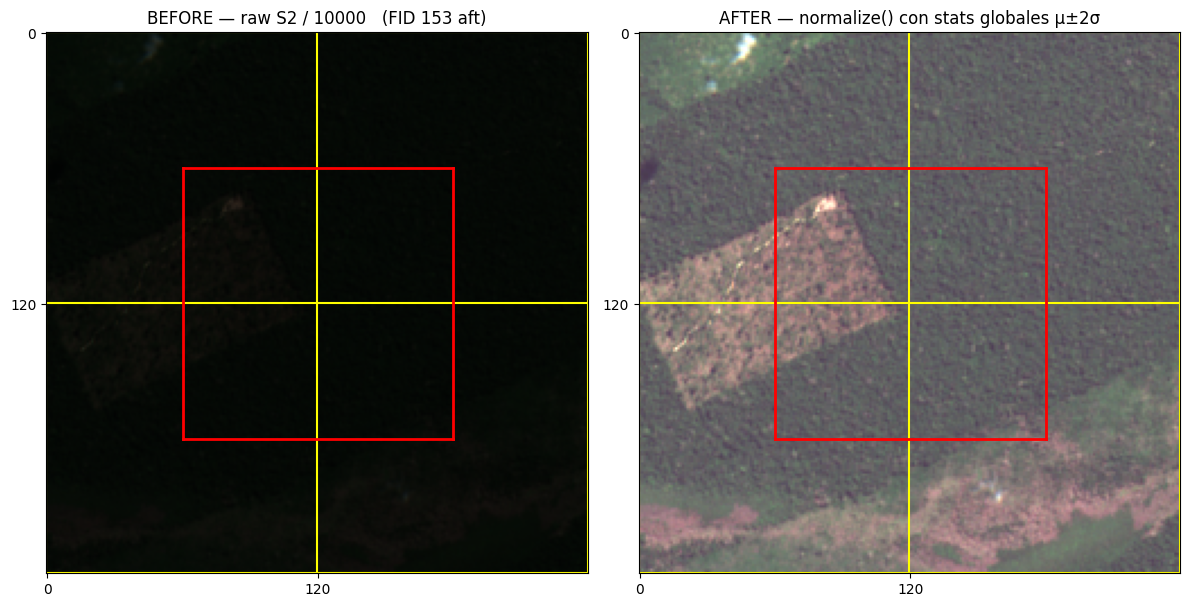

In [8]:
TILE_SIZE_M = TILE_SIZE * 10   # 1200 m per tile

transforms = []
for p in paths:
    with rasterio.open(p) as src:
        transforms.append(src.transform)

cs = [t.c for t in transforms]
fs = [t.f for t in transforms]
x0 = min(cs)
y0 = max(fs)
n_cols = int(round((max(cs) - x0) / TILE_SIZE_M)) + 1
n_rows = int(round((y0 - min(fs)) / TILE_SIZE_M)) + 1

# 1) Build a RAW data mosaic of shape (12, n_rows*120, n_cols*120)
data_mosaic = np.full((12, n_rows * TILE_SIZE, n_cols * TILE_SIZE),
                    np.nan, dtype=np.float32)
for i, p in enumerate(paths):
    with rasterio.open(p) as src:
        t = src.transform
    row = int(round((y0 - t.f) / TILE_SIZE_M))
    col = int(round((t.c - x0) / TILE_SIZE_M))
    data_mosaic[:, row * TILE_SIZE:(row + 1) * TILE_SIZE,
                    col * TILE_SIZE:(col + 1) * TILE_SIZE] = all_data[i]

# 2) Apply normalize() with GLOBAL stats to the batch, then mosaic the result.
x_norm = normalize(torch.from_numpy(all_data), s2_mean, s2_std).cpu().numpy()
norm_mosaic = np.full_like(data_mosaic, np.nan)
for i, p in enumerate(paths):
    with rasterio.open(p) as src:
        t = src.transform
    row = int(round((y0 - t.f) / TILE_SIZE_M))
    col = int(round((t.c - x0) / TILE_SIZE_M))
    norm_mosaic[:, row * TILE_SIZE:(row + 1) * TILE_SIZE,
                    col * TILE_SIZE:(col + 1) * TILE_SIZE] = x_norm[i]

# 3) Pull RGB = (B4, B3, B2) = bands (3, 2, 1) for both versions.
H, W = norm_mosaic.shape[1], norm_mosaic.shape[2]
rgb_before = np.clip(data_mosaic[[3, 2, 1]].transpose(1, 2, 0) / 10000, 0, 1)
rgb_after  = norm_mosaic[[3, 2, 1]].transpose(1, 2, 0)

# 4) Plot side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(rgb_before)
axes[0].set_title(f"BEFORE — raw S2 / 10000   (FID {FID} {WINDOW})")
axes[1].imshow(rgb_after)
axes[1].set_title("AFTER — normalize() con stats globales μ±2σ")

cx = TILE_SIZE // 2 
cy = TILE_SIZE // 2 

# rectangle corners
x0, x1 = cx, cx + TILE_SIZE
y0, y1 = cy, cy + TILE_SIZE

# Rejilla 120x120 sobre AMBOS paneles
for ax in axes:
    for x in range(0, W + 1, TILE_SIZE):
        ax.axvline(x - 0.5, color="yellow", lw=1.5)
    for y in range(0, H + 1, TILE_SIZE):
        ax.axhline(y - 0.5, color="yellow", lw=1.5)
    ax.set_xticks(range(0, W + 1, TILE_SIZE))
    ax.set_yticks(range(0, H + 1, TILE_SIZE))

    # rectangle using lines
    ax.plot([x0, x1], [y0, y0], color="red", lw=2)  # bottom
    ax.plot([x0, x1], [y1, y1], color="red", lw=2)  # top
    ax.plot([x0, x0], [y0, y1], color="red", lw=2)  # left
    ax.plot([x1, x1], [y0, y1], color="red", lw=2)  # right

plt.tight_layout()
plt.show()

### Extract the center patch

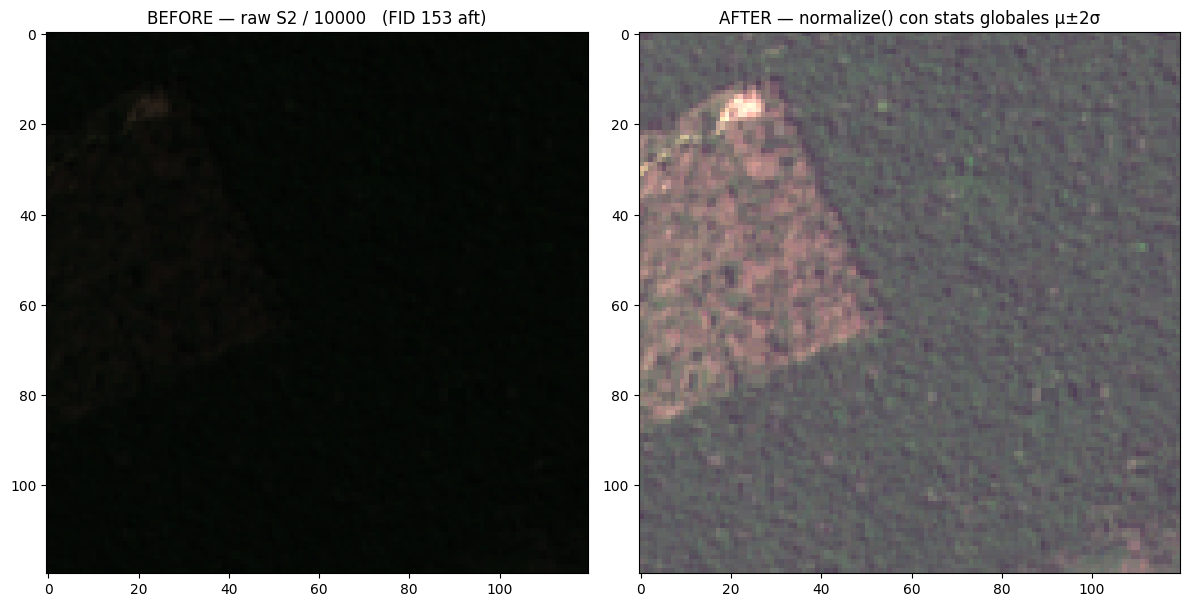

In [9]:
# Extract center patch
center_tile_data = data_mosaic[:,60:180,60:180]
norm_center_tile_data = norm_mosaic[:,60:180,60:180]

# Pull RGB = (B4, B3, B2) = bands (3, 2, 1) for both versions.
H, W = center_tile_data.shape[1], center_tile_data.shape[2]
rgb_center = np.clip(center_tile_data[[3, 2, 1]].transpose(1, 2, 0) / 10000, 0, 1)
rgb_norm_center  = norm_center_tile_data[[3, 2, 1]].transpose(1, 2, 0)

# Plot side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(rgb_center)
axes[0].set_title(f"BEFORE — raw S2 / 10000   (FID {FID} {WINDOW})")
axes[1].imshow(rgb_norm_center)
axes[1].set_title("AFTER — normalize() con stats globales μ±2σ")

plt.tight_layout()
plt.show()

Tokens shape: (1, 15, 15, 768)
scale=8


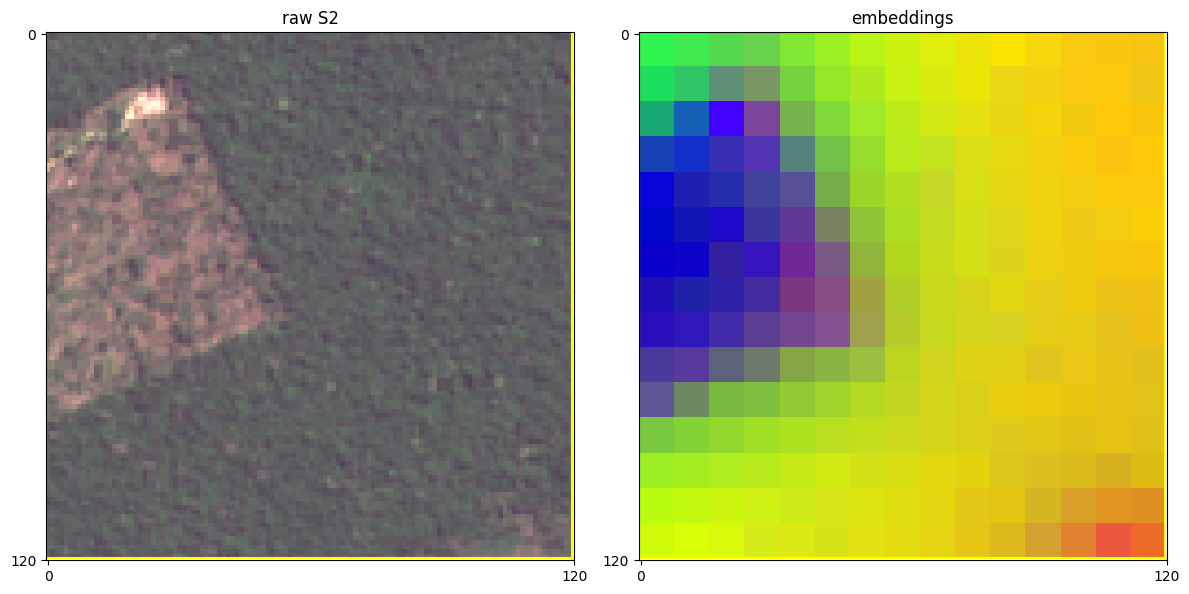

In [10]:
# Embeddings
norm_center_tile_data = norm_center_tile_data[np.newaxis, :]
x = torch.from_numpy(norm_center_tile_data)
x = normalize(x, s2_mean, s2_std).to(device)
tokens = encode(model, x, MODALITY)        # (N, 15, 15, 768)
print(f"Tokens shape: {tokens.shape}")
embed = tokens[0]

scale = norm_center_tile_data.shape[-1] // embed.shape[1]
print(f"scale={scale}")
embed_up = np.kron(embed, np.ones((scale, scale, 1)))
embed_up_norm = (embed_up-embed_up.min(axis=(0,1)))/(embed_up.max(axis=(0,1))- embed_up.min(axis=(0,1)))


# Plot side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(rgb_norm_center)
axes[0].set_title(f"raw S2")
axes[1].imshow(embed_up_norm[:,:,:3])
axes[1].set_title("embeddings")

# Rejilla 120x120 sobre AMBOS paneles
for ax in axes:
    for x in range(0, W + 1, TILE_SIZE):
        ax.axvline(x - 0.5, color="yellow", lw=1.5)
    for y in range(0, H + 1, TILE_SIZE):
        ax.axhline(y - 0.5, color="yellow", lw=1.5)
    ax.set_xticks(range(0, W + 1, TILE_SIZE))
    ax.set_yticks(range(0, H + 1, TILE_SIZE))

plt.tight_layout()
plt.show()

## Embeddings

In [11]:
# Normalize with GLOBAL stats (computed over all S2/S1 tiles) and encode
mean = s2_mean if MODALITY == "optical" else s1_mean
std  = s2_std  if MODALITY == "optical" else s1_std
tiles = torch.from_numpy(all_data)
tiles = normalize(tiles, mean, std).to(device)
tokens = encode(model, tiles, MODALITY)        # (N, 15, 15, 768)
print(f"tiles shape: {tiles.shape}")
print(f"tokens shape: {tokens.shape}")

tiles shape: torch.Size([4, 12, 120, 120])
tokens shape: (4, 15, 15, 768)


In [12]:
# Print values of ONE embedding dimension across all patches of all tiles.
DIM = 0   # pick any dimension in [0, 767]

print(f"Values of dimension {DIM} for each tile (15x15 grid of patches):\n")
for i, t in enumerate(tokens):
    print(f"--- tile {i} (path: {os.path.basename(paths[i])}) ---")
    # t has shape (15, 15, 768); slice the chosen dimension
    plane = t[:, :, DIM]
    np.set_printoptions(precision=3, suppress=True, linewidth=160)
    #print(plane)
    print()


Values of dimension 0 for each tile (15x15 grid of patches):

--- tile 0 (path: tile_0.tif) ---

--- tile 1 (path: tile_1.tif) ---

--- tile 2 (path: tile_2.tif) ---

--- tile 3 (path: tile_3.tif) ---



## Visualisation of the distributions

In [13]:
# mean over spatial tokens for each tile
# shape: (n_tiles, 768)

tile_means = tokens.mean(axis=(1, 2)) #- shape: (4,768)

# variability of each embedding dimension across tiles
dim_scores = tile_means.std(axis=0) #- shape: (768)

# sort dimensions by instability
sorted_dims = np.argsort(dim_scores)[::-1]

# dimensions with the highest variability
top_dim = sorted_dims[0]
print("Most tile-sensitive dimension:", top_dim)
print("Score:", dim_scores[top_dim])

Most tile-sensitive dimension: 37
Score: 0.94982755


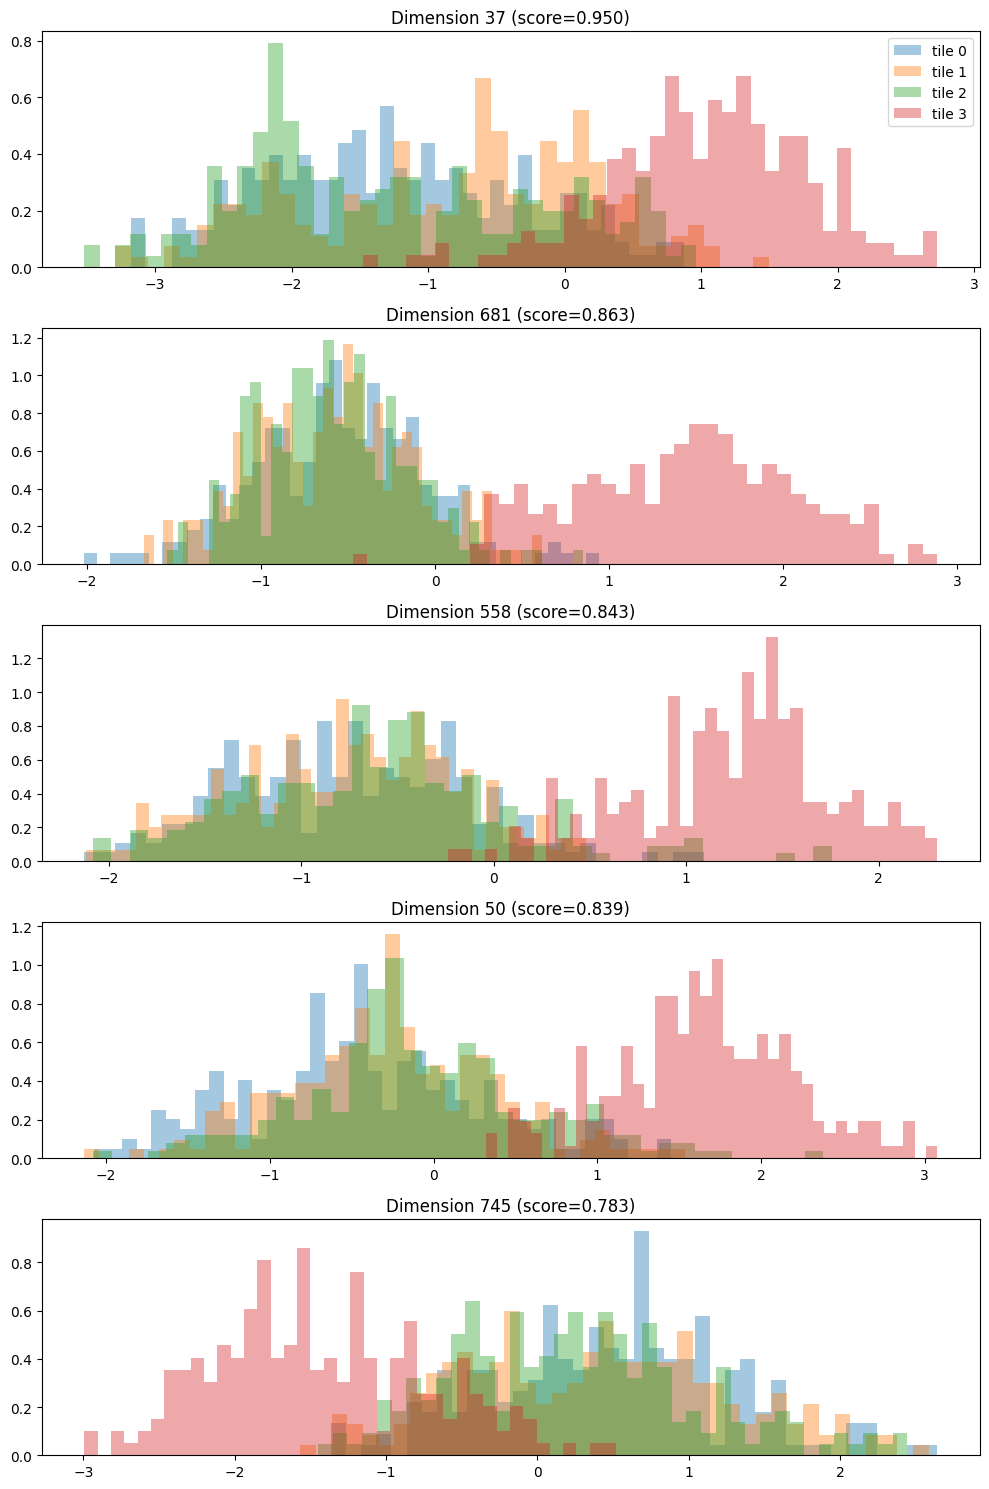

In [14]:
top_k = 5

fig, axes = plt.subplots(top_k, 1, figsize=(10, 3*top_k))

for ax, d in zip(axes, sorted_dims[:top_k]):

    for i in range(tokens.shape[0]):

        vals = tokens[i, :, :, d].ravel()

        ax.hist(
            vals,
            bins=40,
            alpha=0.4,
            density=True,
            label=f"tile {i}"
        )

    ax.set_title(f"Dimension {d} (score={dim_scores[d]:.3f})")

axes[0].legend()

plt.tight_layout()
plt.show()

In [15]:
centered_tokens = tokens - tokens.mean(axis=(1,2),keepdims=True)

# mean over spatial tokens for each tile
# shape: (n_tiles, 768)

tile_means = centered_tokens.mean(axis=(1, 2)) #- shape: (4,768)

# variability of each embedding dimension across tiles
dim_scores = tile_means.std(axis=0) #- shape: (768)

# sort dimensions by instability
sorted_dims = np.argsort(dim_scores)[::-1]

# dimensions with the highest variability
top_dim = sorted_dims[0]
print("Most tile-sensitive dimension:", top_dim)
print("Score:", dim_scores[top_dim])

Most tile-sensitive dimension: 222
Score: 4.6677994e-07


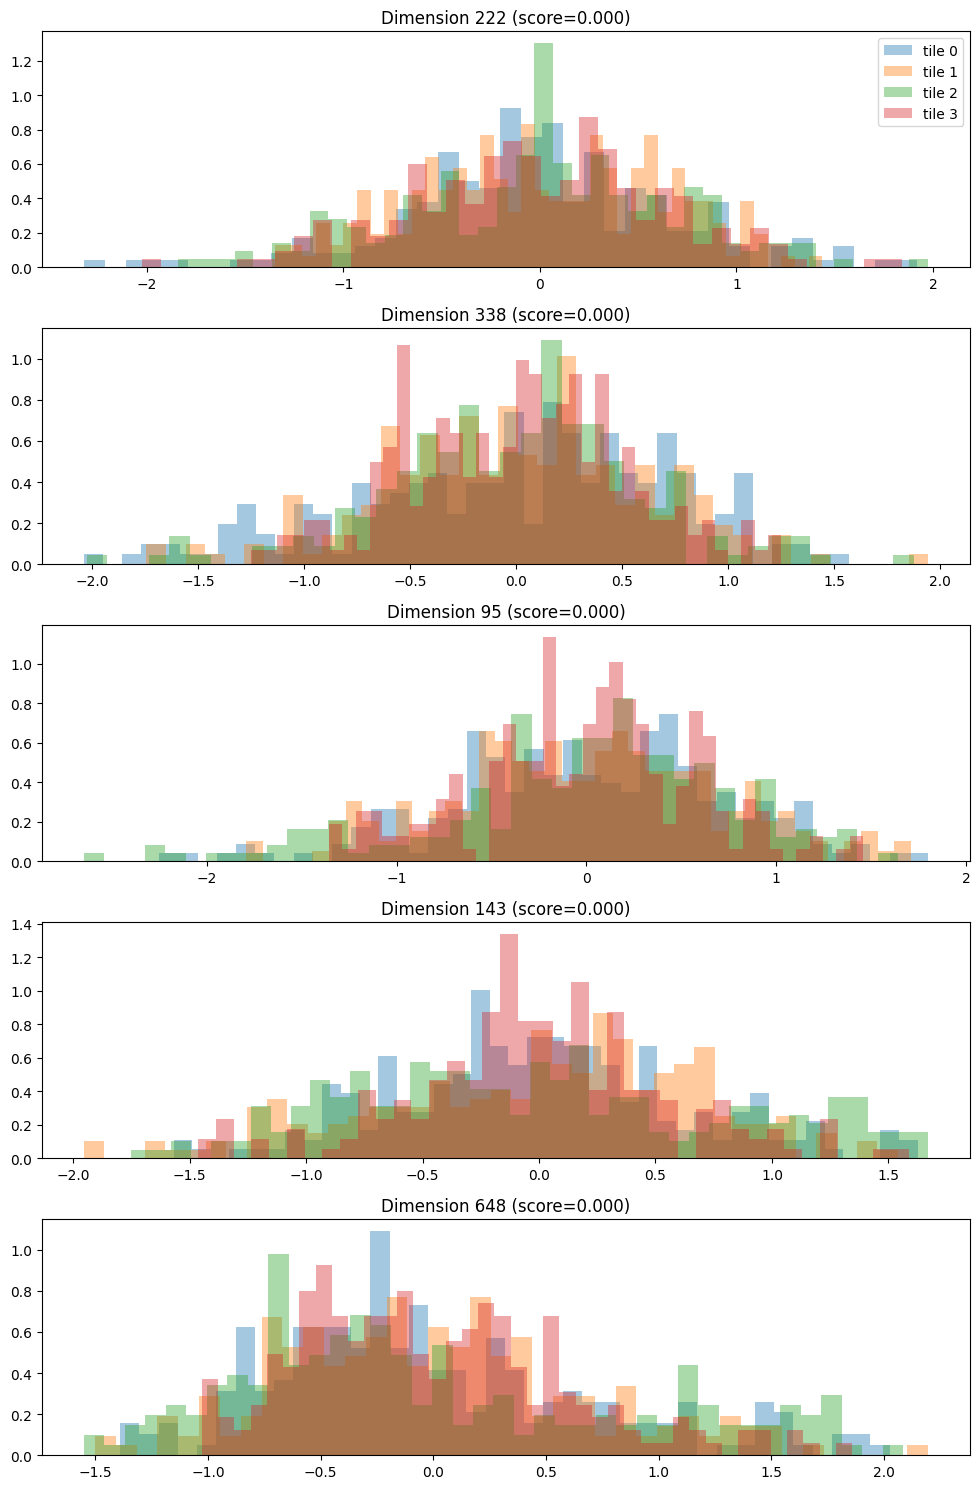

In [16]:
top_k = 5

fig, axes = plt.subplots(top_k, 1, figsize=(10, 3*top_k))

for ax, d in zip(axes, sorted_dims[:top_k]):

    for i in range(tokens.shape[0]):

        vals = centered_tokens[i, :, :, d].ravel()

        ax.hist(
            vals,
            bins=40,
            alpha=0.4,
            density=True,
            label=f"tile {i}"
        )

    ax.set_title(f"Dimension {d} (score={dim_scores[d]:.3f})")

axes[0].legend()

plt.tight_layout()
plt.show()

In [ ]:
TILE_SIZE_M = TILE_SIZE * 10   # 1200 m per tile

transforms = []
for p in paths:
    with rasterio.open(p) as src:
        transforms.append(src.transform)

cs = [t.c for t in transforms]
fs = [t.f for t in transforms]
x0 = min(cs)
y0 = max(fs)
n_cols = int(round((max(cs) - x0) / TILE_SIZE_M)) + 1
n_rows = int(round((y0 - min(fs)) / TILE_SIZE_M)) + 1

# Stitch tile tokens into a mosaic using each tile's geo-coordinates.
mosaic =          np.full((n_rows * GRID_SIZE, n_cols * GRID_SIZE, EMBED_DIM), np.nan, dtype=np.float32)
centered_mosaic = np.full((n_rows * GRID_SIZE, n_cols * GRID_SIZE, EMBED_DIM), np.nan, dtype=np.float32)

for i, p in enumerate(paths):
    with rasterio.open(p) as src:
        t = src.transform
    row = int(round((y0 - t.f) / TILE_SIZE_M))
    col = int(round((t.c - x0) / TILE_SIZE_M))
    mosaic[row * GRID_SIZE:(row + 1) * GRID_SIZE,
           col * GRID_SIZE:(col + 1) * GRID_SIZE, :] = tokens[i]
    centered_mosaic[row * GRID_SIZE:(row + 1) * GRID_SIZE,
           col * GRID_SIZE:(col + 1) * GRID_SIZE, :] = (tokens[i]-tokens[i].mean(axis=(0,1)))

Mosaic: 2x2 tiles -> token grid (30, 30, 768)
mosaic.shape:  (30, 30, 768)
Per-dim min range: [-4.720, -0.242]
Per-dim max range: [0.282, 4.576]
False


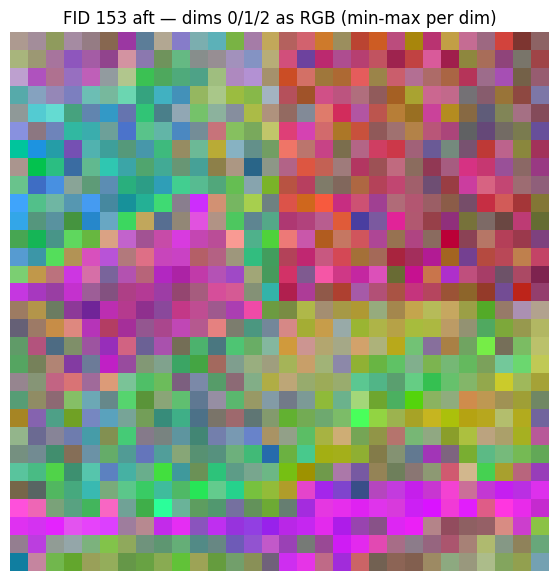

In [18]:
print(f"Mosaic: {n_rows}x{n_cols} tiles -> token grid {mosaic.shape}")
print("mosaic.shape: ", mosaic.shape)
# Global min/max per embedding dimension across ALL valid patches in the mosaic
flat = mosaic.reshape(-1, EMBED_DIM)
valid_mask = ~np.isnan(flat).any(axis=1)
d_min = flat[valid_mask].min(axis=0)     # shape (768,)
d_max = flat[valid_mask].max(axis=0)     # shape (768,)
print(f"Per-dim min range: [{d_min.min():.3f}, {d_min.max():.3f}]")
print(f"Per-dim max range: [{d_max.min():.3f}, {d_max.max():.3f}]")

# Min-max normalize: I_norm = (I - I_min) / (I_max - I_min)
mosaic_norm = (mosaic - d_min) / (d_max - d_min)

# Plot the first 3 dimensions as RGB
rgb = mosaic_norm[:, :, :3]
print(np.isnan(rgb).any())

plt.figure(figsize=(7, 7))
plt.imshow(rgb)
plt.title(f"FID {FID} {WINDOW} — dims 0/1/2 as RGB (min-max per dim)")
plt.axis("off")
plt.show()

Mosaic: 2x2 tiles -> token grid (30, 30, 768)
mosaic.shape:  (30, 30, 768)
Per-dim min range: [-3.644, -1.184]
Per-dim max range: [1.201, 3.733]
False


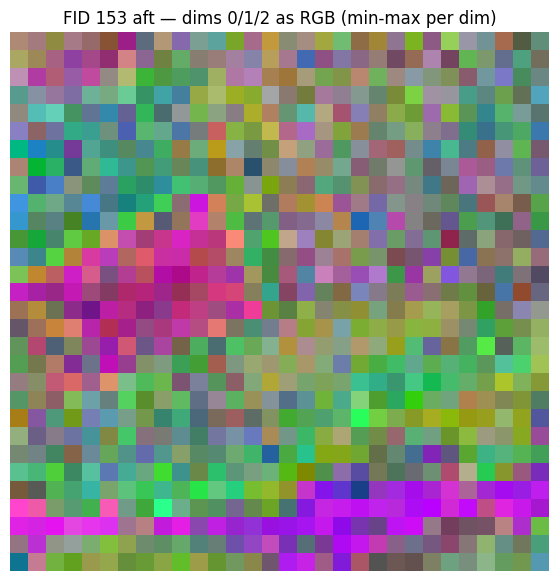

In [19]:
print(f"Mosaic: {n_rows}x{n_cols} tiles -> token grid {centered_mosaic.shape}")
print("mosaic.shape: ", centered_mosaic.shape)
# Global min/max per embedding dimension across ALL valid patches in the mosaic
flat = centered_mosaic.reshape(-1, EMBED_DIM)
valid_mask = ~np.isnan(flat).any(axis=1)
d_min = flat[valid_mask].min(axis=0)     # shape (768,)
d_max = flat[valid_mask].max(axis=0)     # shape (768,)
print(f"Per-dim min range: [{d_min.min():.3f}, {d_min.max():.3f}]")
print(f"Per-dim max range: [{d_max.min():.3f}, {d_max.max():.3f}]")

# Min-max normalize: I_norm = (I - I_min) / (I_max - I_min)
mosaic_norm = (centered_mosaic - d_min) / (d_max - d_min)

# Plot the first 3 dimensions as RGB
rgb = mosaic_norm[:, :, :3]
print(np.isnan(rgb).any())

plt.figure(figsize=(7, 7))
plt.imshow(rgb)
plt.title(f"FID {FID} {WINDOW} — dims 0/1/2 as RGB (min-max per dim)")
plt.axis("off")
plt.show()

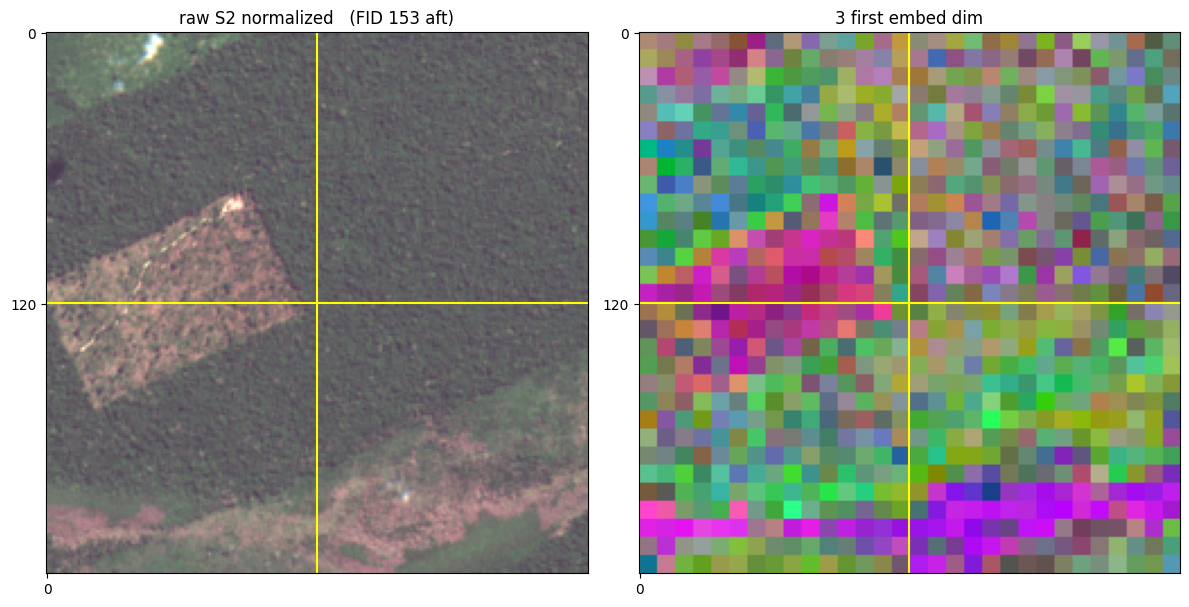

In [20]:
scale = rgb_after.shape[0] // rgb.shape[0]
rgb_up = np.kron(rgb, np.ones((scale, scale, 1)))
# 4) Plot side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(rgb_after)
axes[0].set_title(f"raw S2 normalized   (FID {FID} {WINDOW})")
axes[1].imshow(rgb_up)
axes[1].set_title("3 first embed dim")

# Rejilla 120x120 sobre AMBOS paneles
for ax in axes:
    for x in range(0, W + 1, TILE_SIZE):
        ax.axvline(x - 0.5, color="yellow", lw=1.5)
    for y in range(0, H + 1, TILE_SIZE):
        ax.axhline(y - 0.5, color="yellow", lw=1.5)
    ax.set_xticks(range(0, W + 1, TILE_SIZE*15))
    ax.set_yticks(range(0, H + 1, TILE_SIZE))

plt.tight_layout()
plt.show()

### PCA visualisation

In [21]:
import geopandas as gpd
from matplotlib.patches import Polygon as MplPolygon

# 1) Load shapefile and pick this FID's polygon
SHP_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "data_shp")
#gdf = gpd.read_file(os.path.join(SHP_DIR, "label_polygons.shp"))
#gdf["fid"] = gdf["fid"].astype(int).astype(str)

with rasterio.open(paths[0]) as src:
    mosaic_crs = src.crs

#poly = gdf[gdf["fid"] == str(FID)].to_crs(mosaic_crs).geometry.iloc[0]


def polygon_token_coords(poly, x0, y0, offset_px=(0, 0)):
    """UTM polygon -> token-grid coords (1 token = 8 px).
    offset_px = (py, px) of the standalone chunk inside the mosaic; (0,0) for the full mosaic.
    Returns a list of [(col, row), ...] lists, one per polygon ring."""
    geoms = [poly] if poly.geom_type == "Polygon" else list(poly.geoms)
    rings = []
    for g in geoms: 
        xs, ys = g.exterior.coords.xy
        coords = []
        for vx, vy in zip(xs, ys):
            pcol = (vx - x0) / 10.0
            prow = (y0 - vy) / 10.0
            coords.append(((pcol - offset_px[1]) / PATCH_SIZE,
                            (prow - offset_px[0]) / PATCH_SIZE))
        rings.append(coords)
    return rings

flat shape:  (900, 768)
Explained variance: [0.201 0.115 0.081]
Cumulative:         0.396


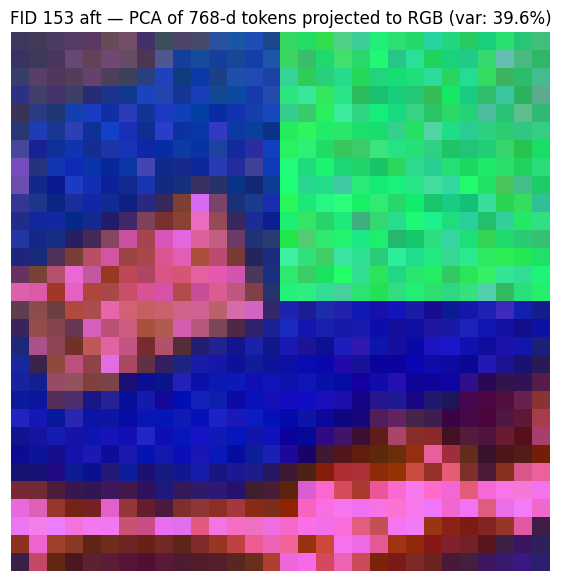

In [22]:
from sklearn.decomposition import PCA

# 1) Flatten the mosaic (H, W, 768) → (N_patches, 768).
flat = mosaic.reshape(-1, EMBED_DIM)
#flat = centered_mosaic.reshape(-1, EMBED_DIM)
print("flat shape: ", flat.shape)

# 2) Fit PCA: find the 3 directions in 768-D space along which patches vary most.
pca = PCA(n_components=3, whiten=True)
projected = pca.fit_transform(flat)                  # (N_patches, 3)
print(f"Explained variance: {pca.explained_variance_ratio_}")
print(f"Cumulative:         {pca.explained_variance_ratio_.sum():.3f}")

# 3) Put the 3 components back into the spatial grid.
pca_rgb = projected.reshape(mosaic.shape[0], mosaic.shape[1], 3)

# 4) Per-channel min-max normalize to [0, 1] for RGB display.
for c in range(3):
     ch = pca_rgb[:, :, c]
     pca_rgb[:, :, c] = (ch - ch.min()) / (ch.max() - ch.min())

# 5) Plot.
plt.figure(figsize=(7, 7))
ax = plt.gca()
ax.imshow(pca_rgb)
#for coords in polygon_token_coords(poly, x0, y0):
#      ax.add_patch(MplPolygon(coords, closed=True,
#                              edgecolor="black", facecolor="red", alpha=0.2, lw=2))

ax.set_title(f"FID {FID} {WINDOW} — PCA of 768-d tokens projected to RGB "
            f"(var: {pca.explained_variance_ratio_.sum():.1%})")
ax.axis("off")
plt.show()


flat shape: (900, 768)


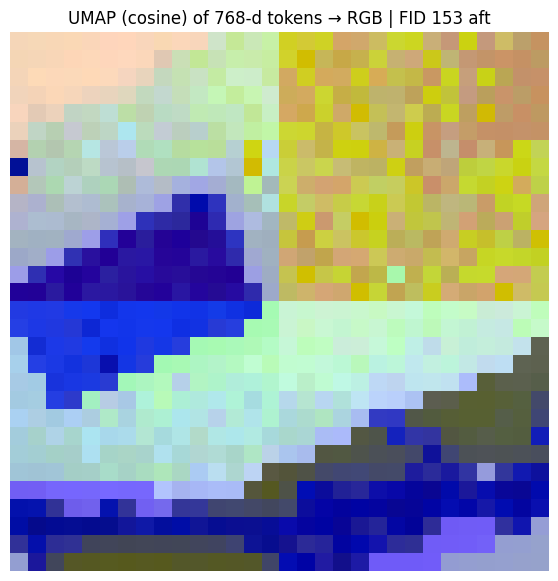

In [23]:
import umap
import numpy as np
import matplotlib.pyplot as plt

# 1) Flatten mosaic: (H, W, 768) → (N, 768)
#flat = mosaic.reshape(-1, EMBED_DIM)
flat = centered_mosaic.reshape(-1, EMBED_DIM)
print("flat shape:", flat.shape)

# Optional but often helpful for cosine UMAP stability
# (removes scale effects)
#flat = flat / (np.linalg.norm(flat, axis=1, keepdims=True) + 1e-8)

# 2) Fit UMAP in cosine space
umap_model = umap.UMAP(
    n_components=3,
    metric="cosine",
    n_neighbors=15,
    min_dist=0.1,
    n_jobs=-1
)

projected = umap_model.fit_transform(flat)   # (N, 3)

# 3) Reshape back to spatial grid
umap_rgb = projected.reshape(mosaic.shape[0], mosaic.shape[1], 3)

# 4) Normalize each channel to [0,1]
for c in range(3):
    ch = umap_rgb[:, :, c]
    umap_rgb[:, :, c] = (ch - ch.min()) / (ch.max() - ch.min() + 1e-8)

# 5) Plot
plt.figure(figsize=(7, 7))
ax = plt.gca()

ax.imshow(umap_rgb)

ax.set_title(
    f"UMAP (cosine) of 768-d tokens → RGB | FID {FID} {WINDOW}"
)
ax.axis("off")

plt.show()

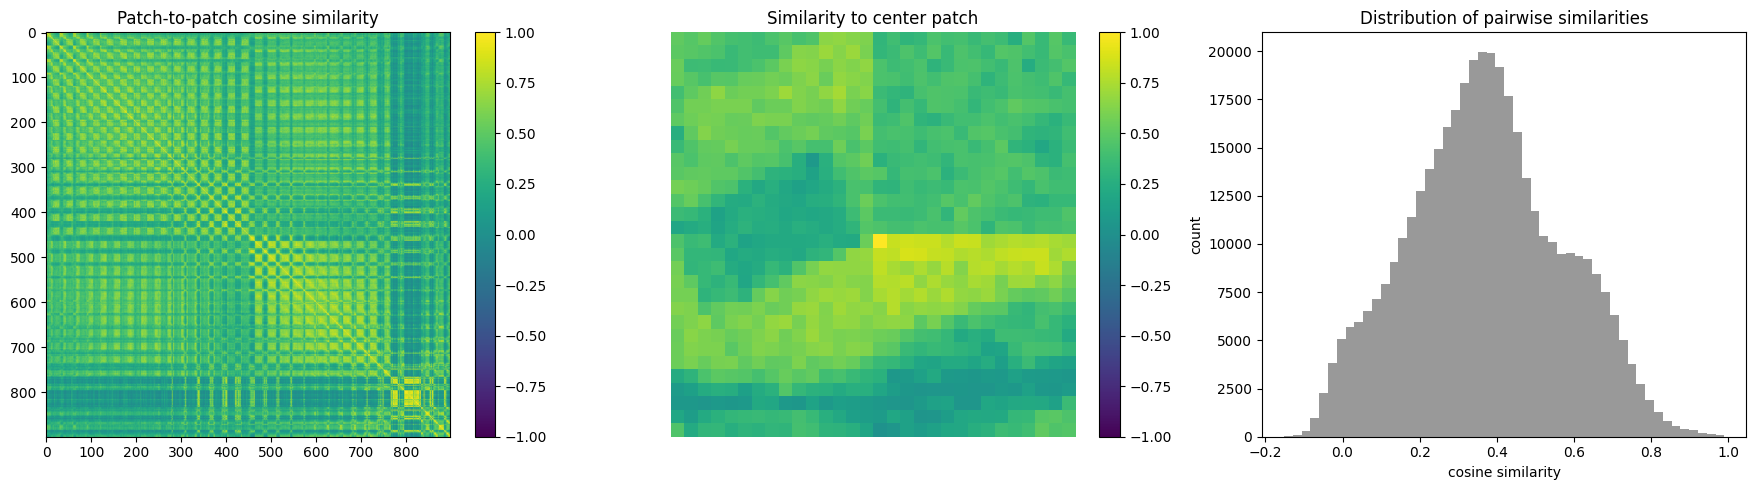

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# -----------------------------
# 1. Flatten mosaic → patches
# -----------------------------
H = W = mosaic.shape[0]
flat = mosaic.reshape(-1, EMBED_DIM)  # (225, 768)
#flat = centered_mosaic.reshape(-1, EMBED_DIM)

# normalize for cosine
flat = flat / (np.linalg.norm(flat, axis=1, keepdims=True) + 1e-8)

# -----------------------------
# 2. Cosine similarity matrix
# -----------------------------
sim = cosine_similarity(flat)  # (225, 225)

# -----------------------------
# 3. Pick center patch
# -----------------------------
center = (H // 2) * W + (W // 2)
sim_map = sim[center].reshape(H, W)

# -----------------------------
# 4. Histogram of similarities
# -----------------------------
sim_values = sim[np.triu_indices_from(sim, k=1)]

# -----------------------------
# 5. Plot everything
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (A) full similarity matrix
im0 = axes[0].imshow(sim, cmap="viridis", vmin=-1, vmax=1)
axes[0].set_title("Patch-to-patch cosine similarity")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# (B) similarity to center patch
im1 = axes[1].imshow(sim_map, cmap="viridis", vmin=-1, vmax=1)
axes[1].set_title("Similarity to center patch")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# (C) histogram of similarities
axes[2].hist(sim_values, bins=50, color="gray", alpha=0.8)
axes[2].set_title("Distribution of pairwise similarities")
axes[2].set_xlabel("cosine similarity")
axes[2].set_ylabel("count")

plt.tight_layout()
plt.show()

# Sliding embeddings

(4, 120, 120, 12)


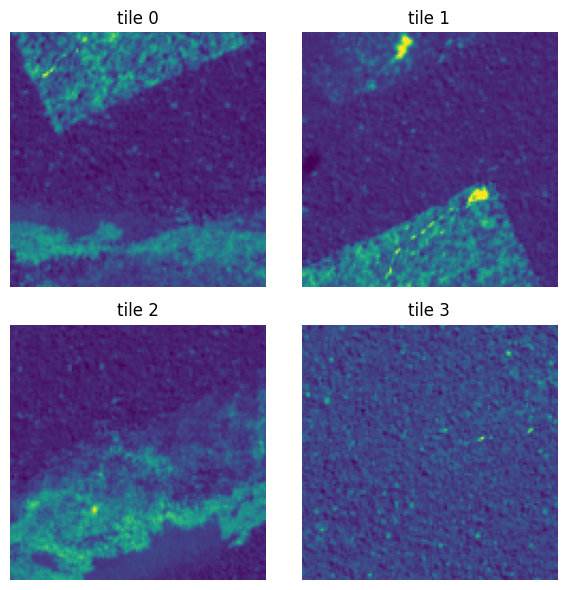

In [25]:
all_tiles = tiles.detach().cpu().numpy()
all_tiles = np.transpose(all_tiles, (0, 2, 3, 1))  # (N, H, W, C)
print(all_tiles.shape)

N = all_tiles.shape[0]
cols = int(np.ceil(np.sqrt(N)))
rows = int(np.ceil(N / cols))

fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))

axes = axes.flatten()

for i in range(N):

    img = all_tiles[i]

    # if normalized, you may need to rescale for visualization
    img_vis = (img - img.min()) / (img.max() - img.min() + 1e-8)

    axes[i].imshow(img_vis[:,:,3])
    axes[i].set_title(f"tile {i}")
    axes[i].axis("off")

# hide empty plots
for j in range(N, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [26]:
ncols, nrows = 2, 2
h, w, c = all_tiles[0].shape
full_tile = np.zeros((nrows*h, ncols*w, c), dtype=all_tiles.dtype)

mapping = {
    1: (0, 0),  # top-left
    3: (0, 1),  # top-right
    0: (1, 0),  # bottom-left
    2: (1, 1),  # bottom-right
}

for i, (r, c_) in mapping.items():
    full_tile[
        r*h:(r+1)*h,
        c_*w:(c_+1)*w,
        :
    ] = all_tiles[i]

(240, 240, 12)


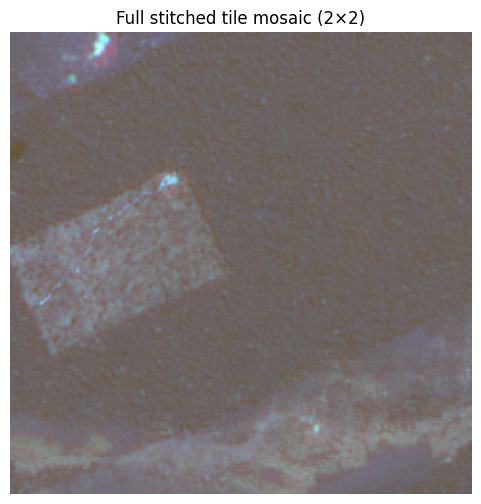

In [27]:
print(full_tile.shape)
img_vis = full_tile.copy()

plt.figure(figsize=(6, 6))
plt.imshow(img_vis[:,:,:3])
plt.title("Full stitched tile mosaic (2×2)")
plt.axis("off")
plt.show()

In [28]:
STRIDE = 8

H, W, C = full_tile.shape

patches = []
coords = []

for i in range(0, H - TILE_SIZE + 1, STRIDE):
    for j in range(0, W - TILE_SIZE + 1, STRIDE):

        patch = full_tile[i:i+TILE_SIZE, j:j+TILE_SIZE, :]
        patches.append(patch)
        coords.append((i, j))

patches = np.stack(patches)  # (N_patches, 120, 120, C)

print("patches:", patches.shape)

patches: (256, 120, 120, 12)


In [29]:
x = torch.from_numpy(patches).permute(0, 3, 1, 2).float()
x = x.to(device)
patch_tokens = encode(model, x, MODALITY)  
print(patch_tokens.shape)

(256, 15, 15, 768)


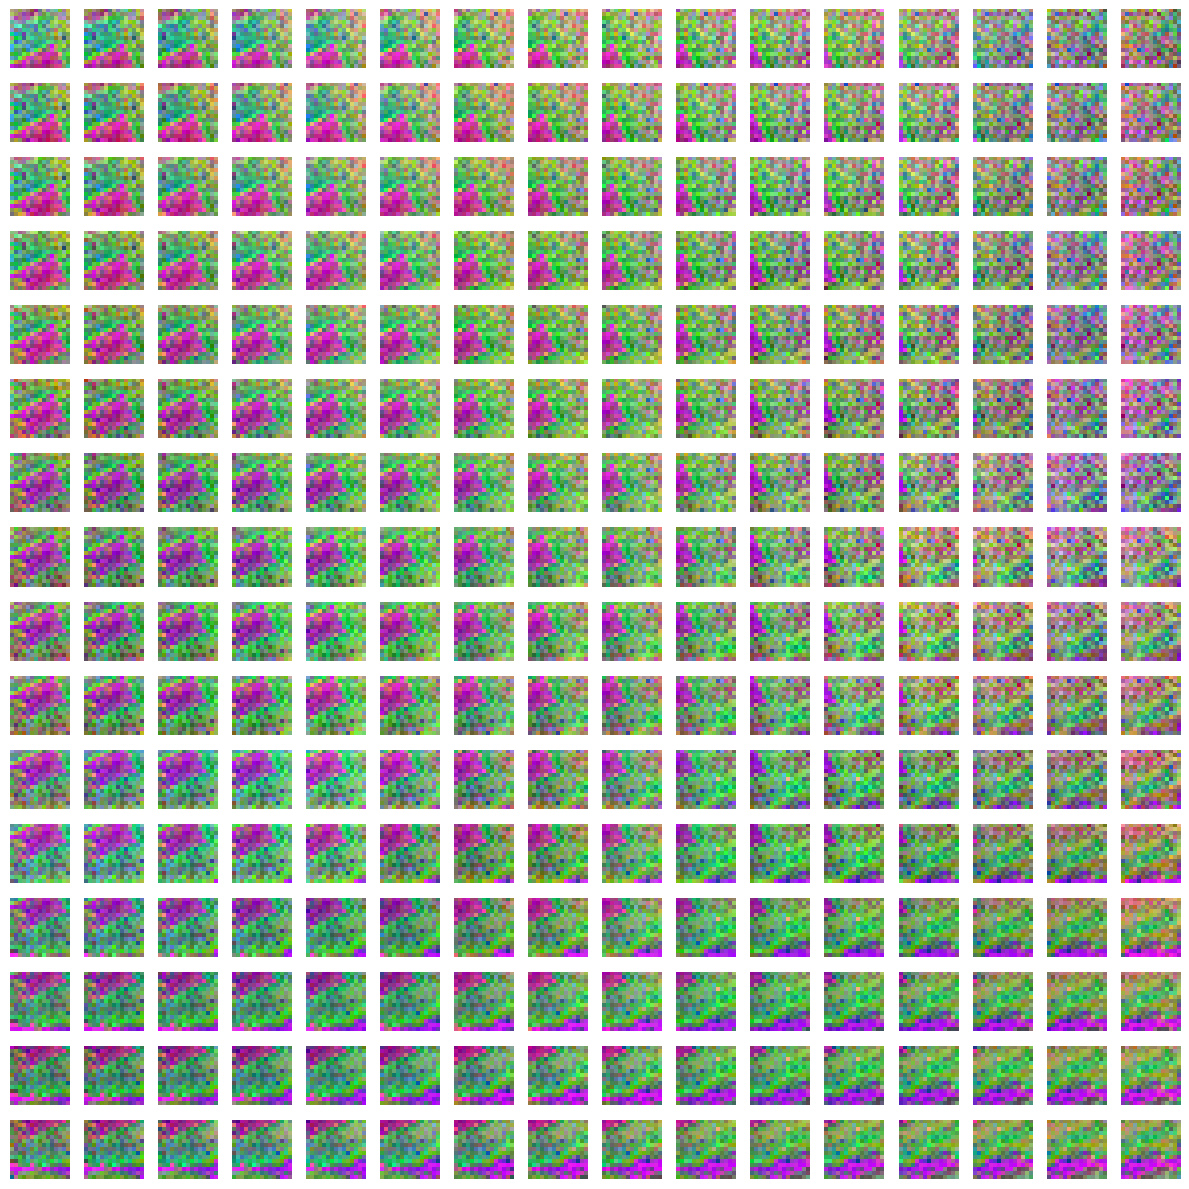

In [30]:
from math import sqrt
p2 = int(sqrt(patch_tokens.shape[0]))

fig, axes = plt.subplots(p2, p2, figsize=(12, 12))

for i, ax in enumerate(axes.flat):
    img = patch_tokens[i, :, :, :3].copy()
    
    for c in range(3):
        ch = img[:, :, c]
        img[:, :, c] = (ch - ch.min()) / (ch.max() - ch.min())
    
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [31]:
# Compute the full token map by averaging computed embeddings (+ compute the std)
H, W = 30, 30
D = patch_tokens.shape[-1]

sum_map = np.zeros((H, W, D), dtype=np.float32)
sq_map  = np.zeros((H, W, D), dtype=np.float32)
count   = np.zeros((H, W, 1), dtype=np.float32)

TOKEN_SIZE = TILE_SIZE // PATCH_SIZE

for k in range(patch_tokens.shape[0]):

    i, j = coords[k]  # pixel coords of patch top-left
    ti0, tj0 = i // STRIDE, j // STRIDE  # convert to 30x30 grid offset
    tokens = patch_tokens[k]  # (15,15,768)
    for ti in range(TOKEN_SIZE):
        for tj in range(TOKEN_SIZE):
            ii = ti + ti0 * STRIDE // PATCH_SIZE
            jj = tj + tj0 * STRIDE // PATCH_SIZE
            if ii >= H or jj >= W:
                continue

            v = tokens[ti, tj]

            sum_map[ii, jj] += v
            sq_map[ii, jj] += v * v
            count[ii, jj] += 1

mean_map = sum_map / (count + 1e-8)
var_map  = (sq_map / (count + 1e-8)) - mean_map**2
std_map  = np.sqrt(np.clip(var_map, 0, None))

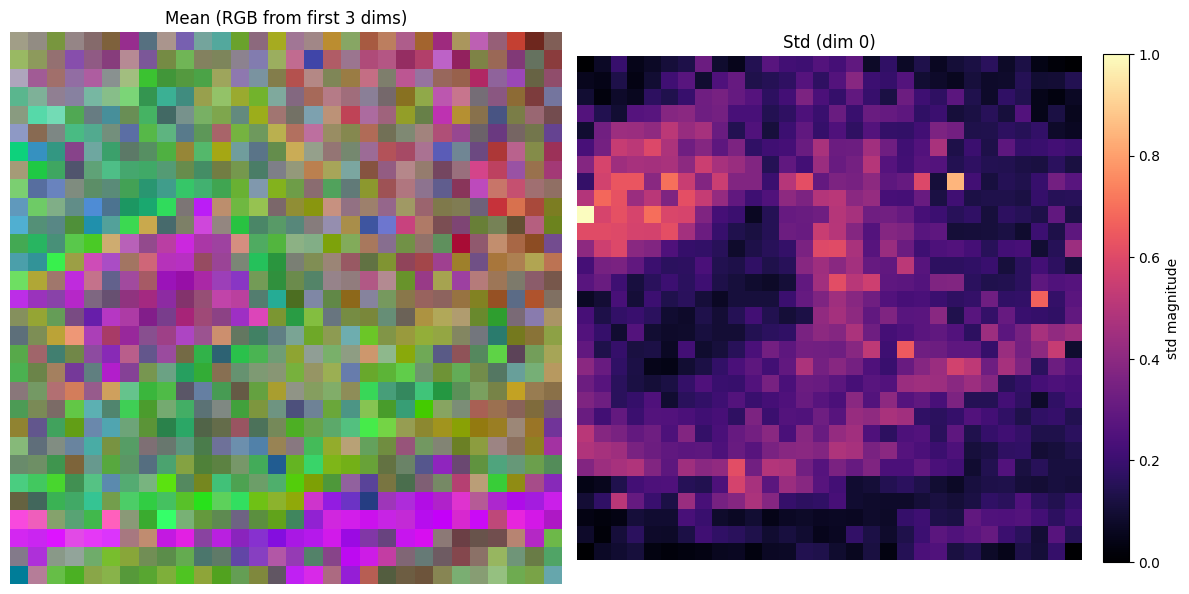

In [32]:
def norm(x):
    return (x - np.min(x, axis=(0,1)))/(np.max(x, axis=(0,1))-np.min(x, axis=(0,1)))
    

mean_rgb = mean_map[:, :, :3]
std_rgb = std_map[:, :, :3]

mean_vis = norm(mean_rgb)
std_vis = norm(std_rgb)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

im0 = axes[0].imshow(mean_vis)
axes[0].set_title("Mean (RGB from first 3 dims)")
axes[0].axis("off")

im1 = axes[1].imshow(std_vis[:, :, 0], cmap="magma")
axes[1].set_title("Std (dim 0)")
axes[1].axis("off")

cbar = plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
cbar.set_label("std magnitude")

plt.tight_layout()
plt.show()

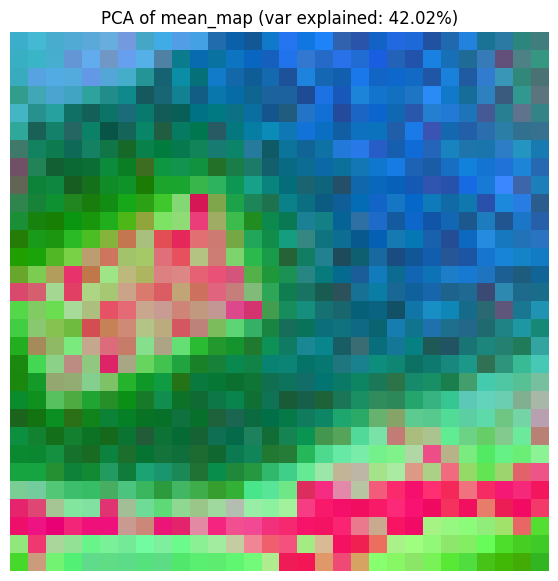

In [33]:
# PCA

flat = mean_map.reshape(-1, mean_map.shape[-1])

pca = PCA(n_components=3)
proj = pca.fit_transform(flat)

pca_rgb = proj.reshape(H, W, 3)

for c in range(3):
    ch = pca_rgb[:, :, c]
    pca_rgb[:, :, c] = (ch - ch.min()) / (ch.max() - ch.min() + 1e-8)

plt.figure(figsize=(7, 7))
plt.imshow(pca_rgb)
plt.title(
    f"PCA of mean_map "
    f"(var explained: {pca.explained_variance_ratio_.sum():.2%})"
)
plt.axis("off")
plt.show()

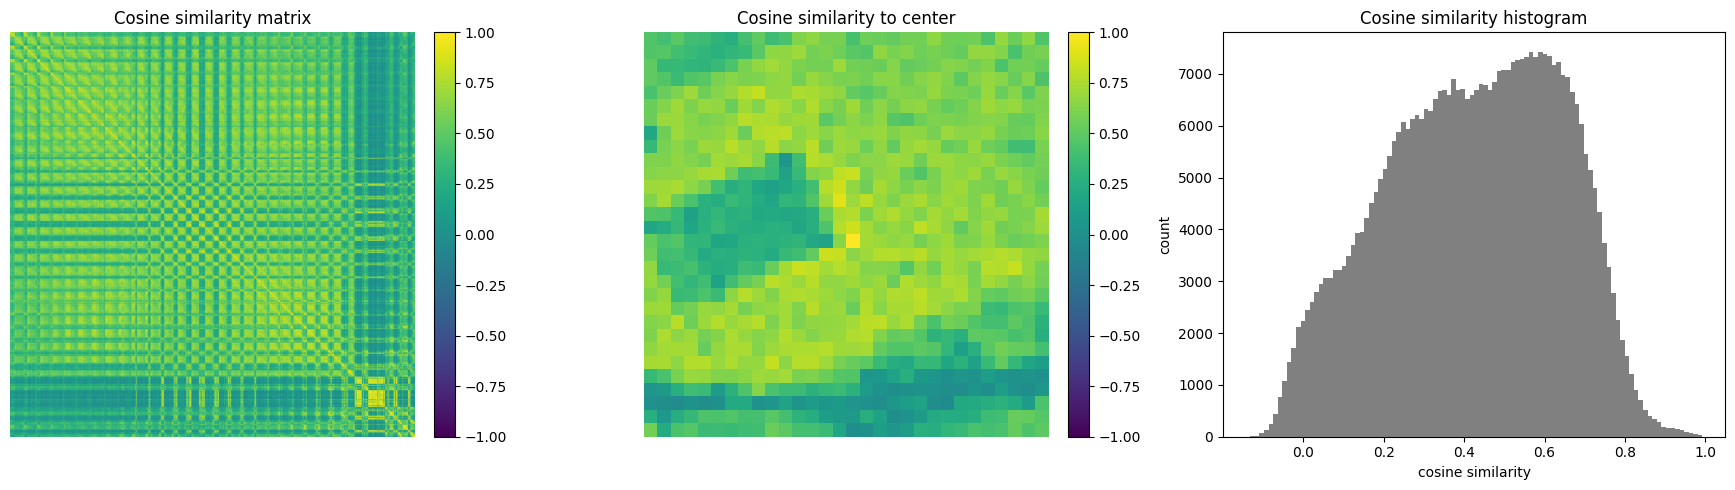

In [34]:
# Cosine similarity analysis

flat = mean_map.reshape(-1, mean_map.shape[-1])
flat = flat / (np.linalg.norm(flat, axis=1, keepdims=True))

cos_sim = flat @ flat.T

center = (30 // 2) * 30 + (30 // 2)
sim_center = cos_sim[center].reshape(30, 30)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(cos_sim, cmap="viridis", vmin=-1, vmax=1)
axes[0].set_title("Cosine similarity matrix")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(sim_center, cmap="viridis", vmin=-1, vmax=1)
axes[1].set_title("Cosine similarity to center")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

vals = cos_sim[np.triu_indices(cos_sim.shape[0], k=1)]
axes[2].hist(vals, bins=100, color="gray")
axes[2].set_title("Cosine similarity histogram")
axes[2].set_xlabel("cosine similarity")
axes[2].set_ylabel("count")

plt.tight_layout()
plt.show()

### Embedding with disturbance polygon centralized

In [ ]:
import geopandas as gpd
from sklearn.decomposition import PCA

# ── 1) load the polygon ─────────────────────────────────────────────────────
SHP_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "data_shp")
shp_path = os.path.join(SHP_DIR, "label_polygons.shp")
gdf = gpd.read_file(shp_path)
gdf["fid"] = gdf["fid"].astype(int).astype(str)

with rasterio.open(paths[0]) as src:                # CRS del mosaico = CRS de cualquier tile
    mosaic_crs = src.crs

poly_row = gdf[gdf["fid"] == str(FID)]
assert not poly_row.empty, f"There is not polygon for the fid {FID}"
poly = poly_row.to_crs(mosaic_crs).geometry.iloc[0]

# ── 2) UTM centroid → pixel position in data_mosaic ──────────────────────────
cx, cy = poly.centroid.x, poly.centroid.y       # polygon centroid in UTM meters
center_row = (y0 - cy) / 10.0                    # 10 m/pixel; geographic Y decreases downward
center_col = (cx - x0) / 10.0
print(f"Polygon centroid: UTM=({cx:.1f}, {cy:.1f})  pixel=({center_row:.1f}, {center_col:.1f})")

# ── 3) Top-left of a 120x120 chunk centered on the centroid ──────────────────
#    Snap to a multiple of 8 px so it aligns with the ViT patch grid.
py = int(round(center_row - TILE_SIZE / 2))
px = int(round(center_col - TILE_SIZE / 2))
py = (py // PATCH_SIZE) * PATCH_SIZE
px = (px // PATCH_SIZE) * PATCH_SIZE


In [ ]:
# Clip to the mosaic borders (in case the polygon is near an edge)
H, W = data_mosaic.shape[1], data_mosaic.shape[2]
py = max(0, min(py, H - TILE_SIZE))
px = max(0, min(px, W - TILE_SIZE))
print(f"Chunk top-left: row={py}, col={px}   (mosaic is {H}x{W} px)")

# Slice the chunk and validate
chunk = data_mosaic[:, py:py+TILE_SIZE, px:px+TILE_SIZE]
assert not np.isnan(chunk).any(), "Chunk centered on the polygon crosses missing tiles."

# Encode standalone centralized chunk
chunk_t = torch.from_numpy(chunk).unsqueeze(0)
chunk_t = normalize(chunk_t, s2_mean, s2_std).to(device)
tokens_solo = encode(model, chunk_t, "optical")[0]    # (15, 15, 768)

# 6) Tokens correspondientes del mosaico ya cosido tile-a-tile 
ty, tx = py // PATCH_SIZE, px // PATCH_SIZE # /8
tokens_stitched = mosaic[ty:ty+GRID_SIZE, tx:tx+GRID_SIZE, :]    # (15, 15, 768)

# 7) PCA plot 
chunk_proj = pca.transform(tokens_solo.reshape(-1, EMBED_DIM)) \
                .reshape(GRID_SIZE, GRID_SIZE, 3)

#normalize the chunk_rgb
# chunk_rgb = chunk_proj.copy() 
# for c in range(3):
#     lo, hi = chunk_rgb[..., c].min(), chunk_rgb[..., c].max()
#     chunk_rgb[..., c] = (chunk_rgb[..., c] - lo) / (hi - lo + 1e-10)

plt.figure(figsize=(6, 6))
ax = plt.gca()
ax.imshow(chunk_proj)

for coords in polygon_token_coords(poly, x0, y0, offset_px=(py, px)):
    ax.add_patch(MplPolygon(coords, closed=True,
                            edgecolor="red", facecolor="none",
                            linewidth=3, zorder=10))

ax.set_xlim(-0.5, GRID_SIZE - 0.5)
ax.set_ylim(GRID_SIZE - 0.5, -0.5)
ax.set_title(f"Standalone 120x120 — PCA + polygon   (FID {FID} {WINDOW})")
ax.axis("off")
plt.tight_layout()  
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Left: full mosaic PCA
axes[0].imshow(pca_rgb)
for coords in polygon_token_coords(poly, x0, y0):
    axes[0].add_patch(MplPolygon(coords, closed=True,
                                edgecolor="black", facecolor="red",
                                alpha=0.2, lw=2))
axes[0].set_title(f"Mosaic PCA — FID {FID} {WINDOW} "
                f"(var: {pca.explained_variance_ratio_.sum():.1%})")
axes[0].axis("off")

# Right: standalone chunk PCA
axes[1].imshow(chunk_proj)
for coords in polygon_token_coords(poly, x0, y0, offset_px=(py, px)):
    axes[1].add_patch(MplPolygon(coords, closed=True,
                                edgecolor="red", facecolor="none",
                                linewidth=3, zorder=10))
axes[1].set_xlim(-0.5, GRID_SIZE - 0.5)
axes[1].set_ylim(GRID_SIZE - 0.5, -0.5)
axes[1].set_title(f"Standalone 120x120 chunk PCA — FID {FID} {WINDOW}")
axes[1].axis("off")

plt.tight_layout()
plt.show()